In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [7]:
df=pd.read_csv("german_credit_data.csv")

In [8]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [9]:
df['Age'].describe()

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

In [10]:
df['Risk'].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [11]:
df.shape

(1000, 11)

In [12]:
df.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [13]:
df = df.drop(columns=['Unnamed: 0'])

In [14]:
df=df.dropna().reset_index(drop=True)

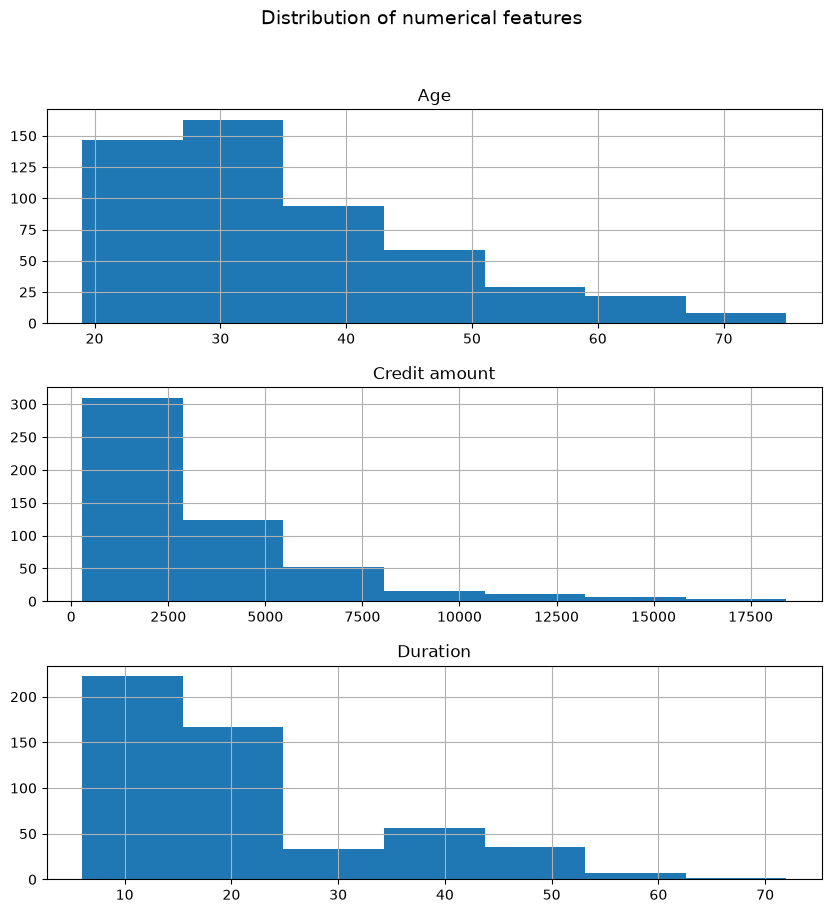

In [15]:
df[['Age','Credit amount','Duration']].hist(bins=7,figsize=(10,10),layout=(3,1))
plt.suptitle("Distribution of numerical features",fontsize=14)
plt.show()

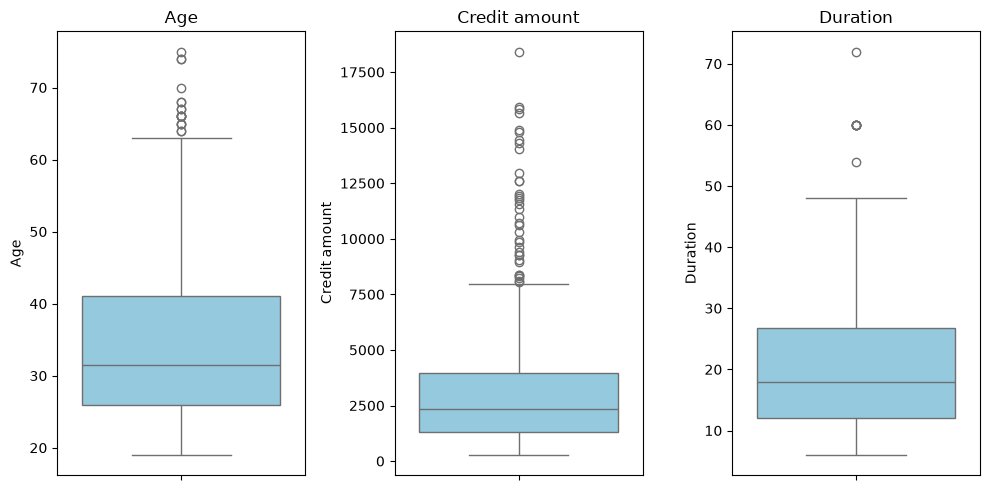

In [16]:
plt.figure(figsize=(10,5))
for i,col in enumerate(['Age','Credit amount','Duration']):
  plt.subplot(1,3,i+1)
  sns.boxplot(y=df[col],color='skyblue')
  plt.title(col)

plt.tight_layout()
plt.show()


In [17]:
df.query('Duration>=60')

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


In [18]:
categorical_cols=['Sex','Job','Housing','Saving accounts','Checking account','Purpose']

C:\Users\rites\AppData\Local\Temp\ipykernel_45336\2688165625.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x=col,palette='Set2',order=df[col].value_counts().index)
C:\Users\rites\AppData\Local\Temp\ipykernel_45336\2688165625.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x=col,palette='Set2',order=df[col].value_counts().index)
C:\Users\rites\AppData\Local\Temp\ipykernel_45336\2688165625.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x=col,palette='Set2',order=df[col].value_counts().index)
C:\User

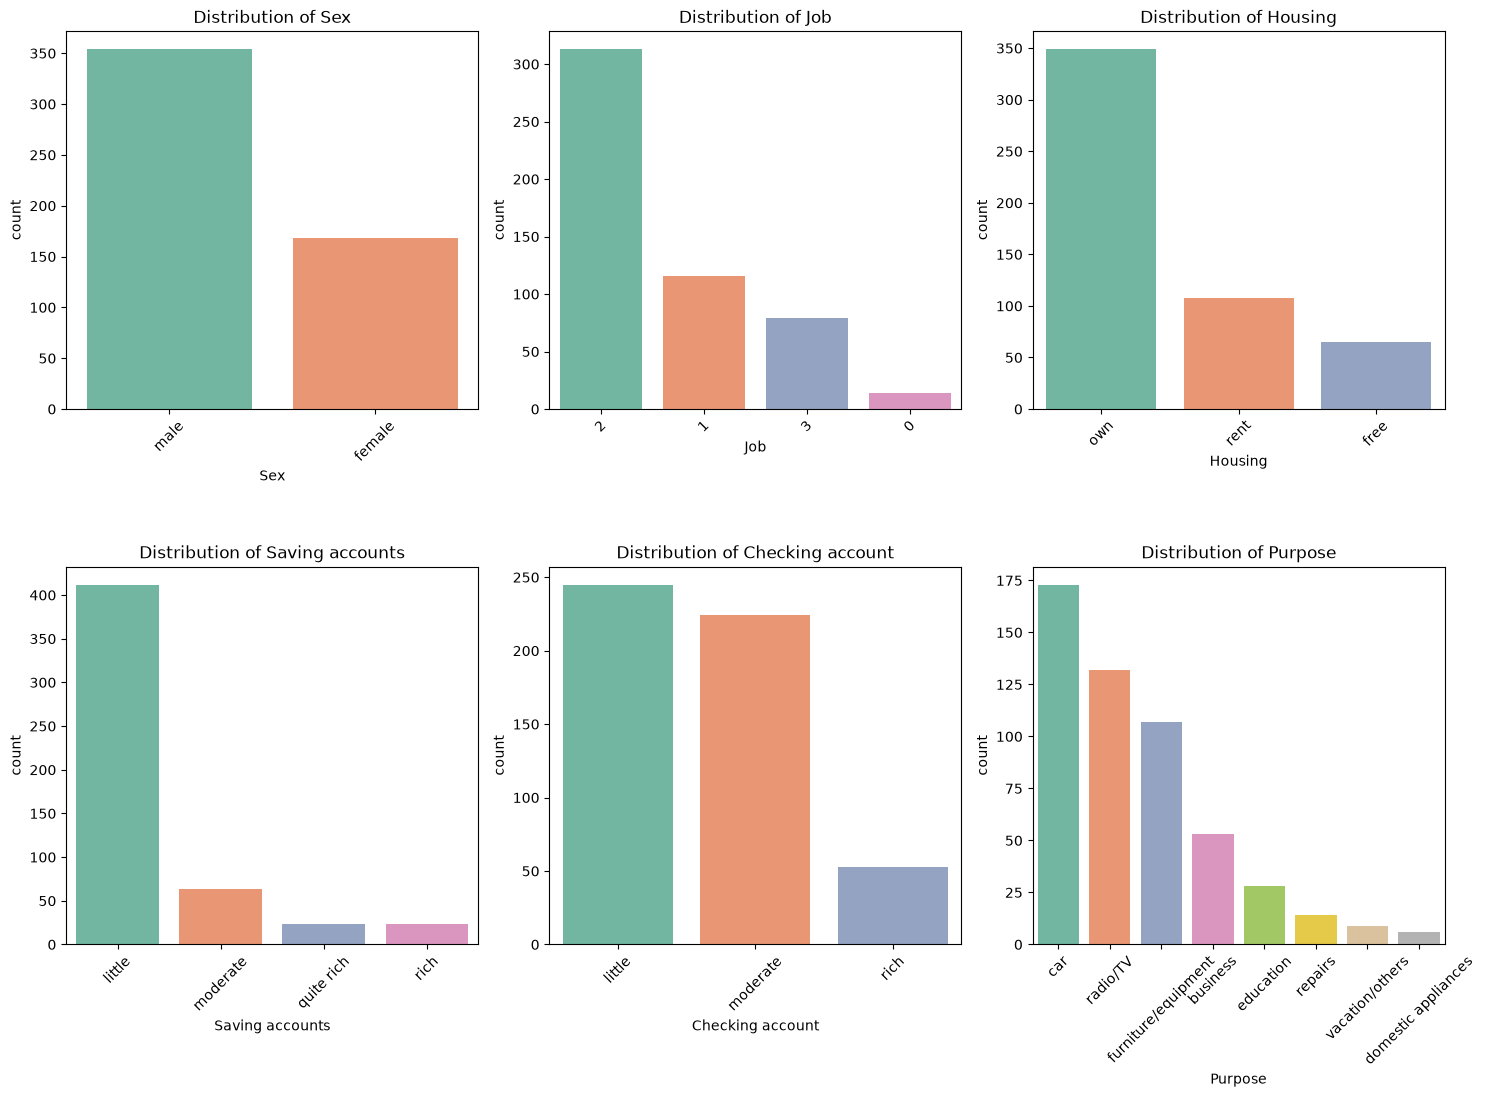

In [19]:
plt.figure(figsize=(15,15))
for i,col in enumerate(categorical_cols):
  plt.subplot(3,3,i+1)
  sns.countplot(data=df,x=col,palette='Set2',order=df[col].value_counts().index)
  plt.title(f"Distribution of {col}")
  plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
corr=df[['Age','Job','Credit amount','Duration']].corr()

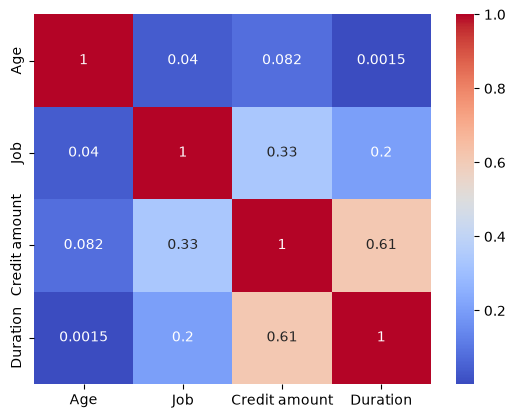

In [21]:
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()


In [22]:
df.groupby('Job')['Credit amount'].mean()

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [23]:
df.groupby('Sex')['Credit amount'].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

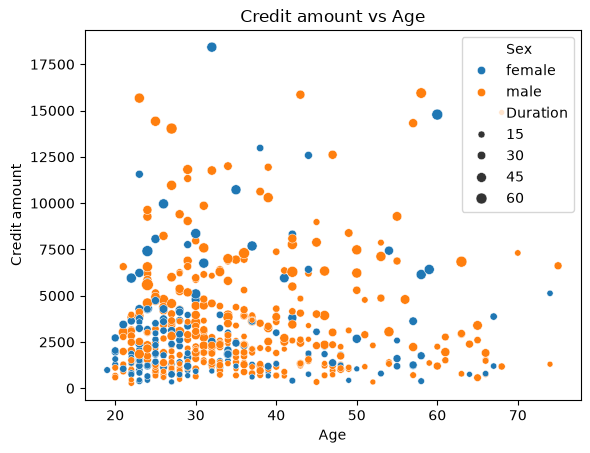

In [24]:
sns.scatterplot(data=df,x='Age',y='Credit amount',hue='Sex',size='Duration')
plt.title("Credit amount vs Age")
plt.show()

C:\Users\rites\AppData\Local\Temp\ipykernel_45336\1370525520.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='Risk',y=col,palette='Pastel2')
C:\Users\rites\AppData\Local\Temp\ipykernel_45336\1370525520.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='Risk',y=col,palette='Pastel2')
C:\Users\rites\AppData\Local\Temp\ipykernel_45336\1370525520.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='Risk',y=col,palette='Pastel2')


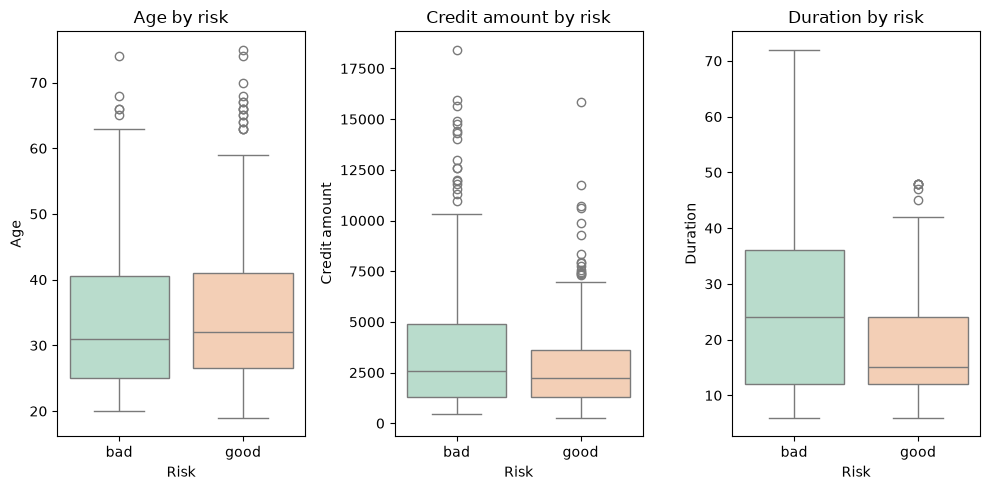

In [25]:
plt.figure(figsize=(10,5))
for i,col in enumerate(['Age','Credit amount','Duration']):
  plt.subplot(1,3,i+1)
  sns.boxplot(data=df,x='Risk',y=col,palette='Pastel2')
  plt.title(f'{col} by risk')

plt.tight_layout()
plt.show()

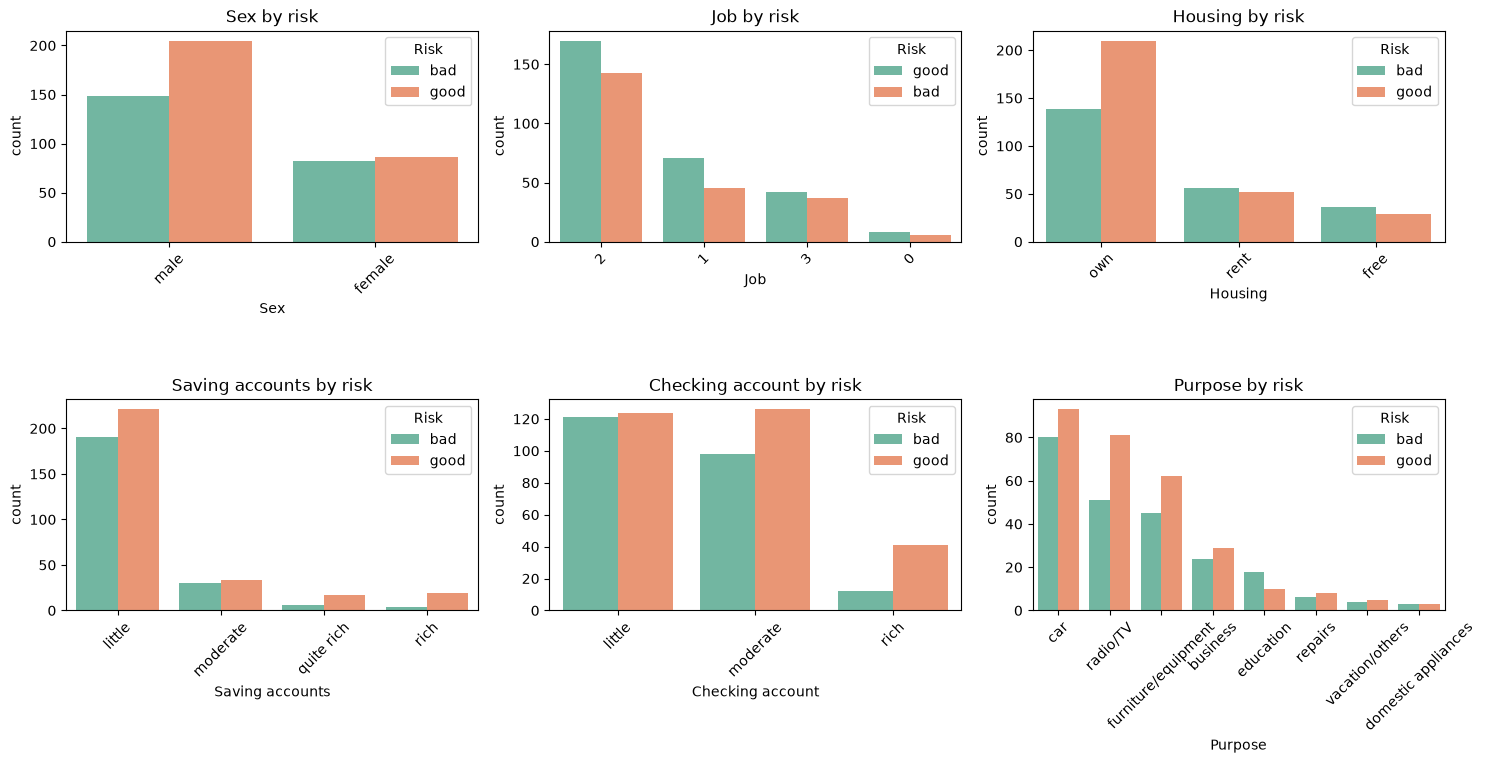

In [26]:
plt.figure(figsize=(15,10))
for i,col in enumerate(categorical_cols):
  plt.subplot(3,3,i+1)
  sns.countplot(data=df,x=col,hue='Risk',palette='Set2',order=df[col].value_counts().index)
  plt.title(f'{col} by risk')
  plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [82]:
features=['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration']
target='Risk'

In [84]:
df_model=df[features+[target]].copy()

In [85]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [86]:
cat_cols=df_model.select_dtypes(include='object').columns.drop('Risk')

In [87]:
le_dict={}

In [88]:
for col in cat_cols:
  le=LabelEncoder()
  df_model[col]=le.fit_transform(df_model[col])
  le_dict[col]=le
  joblib.dump(le,f'{col}_encoder.pkl')

In [89]:
le_target=LabelEncoder()

In [90]:
df_model[target] = le_target.fit_transform(df_model[target])

In [92]:
df_model[target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [93]:
joblib.dump(le_target,'target_encoder.pkl')

['target_encoder.pkl']

In [94]:
from sklearn.model_selection import train_test_split
X = df_model.drop("Risk", axis=1)
y = df_model["Risk"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [101]:
!pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
    --------------------------------------- 0.8/48.9 MB 4.8 MB/s eta 0:00:11
   - -------------------------------------- 1.8/48.9 MB 4.8 MB/s eta 0:00:10
   -- ------------------------------------- 2.6/48.9 MB 4.6 MB/s eta 0:00:11
   -- ------------------------------------- 3.4/48.9 MB 4.4 MB/s eta 0:00:11
   --- ------------------------------------ 4.2/48.9 MB 4.1 MB/s eta 0:00:11
   --- ------------------------------------ 4.7/48.9 MB 4.0 MB/s eta 0:00:12
   ---- ----------------------------------- 5.5/48.9 MB 3.9 MB/s eta 0:00:12
   ----- ---------------------------------- 6.3/48.9 MB 3.9 MB/s eta 0:00:11
   ----- ---------------------------------- 7.1/48.9 MB 3.9 MB/s eta 0:00:11
   ------ --------------------------------- 7.9/48.9 MB 3.8 MB/s eta 0:00:11
   ------- -------------------------------- 8.9/48.9 MB 3.8 MB/s eta 0:00:11
   ------- -------------------------------- 9.7/48.9 MB 3.9 MB/s eta 0:00:11
   ---

In [102]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [103]:
def train_model(model,param_grid,X_train,y_train,X_test,y_test):
    grid=GridSearchCV(model,param_grid,cv=5,scoring='accuracy',n_jobs=-1)
    grid.fit(X_train,y_train)
    best_model=grid.best_estimator_
    y_pred=best_model.predict(X_test)
    acc=accuracy_score(y_test,y_pred)
    return best_model,acc,grid.best_params_

In [107]:
dt=DecisionTreeClassifier(random_state=1,class_weight='balanced')
dt_param_grid={
    'max_depth':[3,5,7,10,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf' :[1,2,4]
}

In [108]:
best_dt,acc_dt,params_dt=train_model(dt,dt_param_grid,X_train,y_train,X_test,y_test)


In [110]:
print('dt accuracy',acc_dt)
print('best params',params_dt)

dt accuracy 0.6
best params {'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 10}


In [113]:
rf=RandomForestClassifier(random_state=1,class_weight='balanced',n_jobs=-1)
rf_param_grid={
    'n_estimators':[100,200],
    'max_depth':[5,7,10,None],
    'min_samples_leaf':[1,2,4]
}

In [114]:
best_rf,acc_rf,params_rf=train_model(rf,rf_param_grid,X_train,y_train,X_test,y_test)

In [116]:
print('rf accuracy',acc_rf)
print('best params',params_rf)

rf accuracy 0.6476190476190476
best params {'max_depth': 10, 'min_samples_leaf': 4, 'n_estimators': 100}


In [117]:
xgb=XGBClassifier(random_state=1,scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(),use_label_encoder=False,eval_metric='logloss')

In [118]:
xgb_param_grid={
    'n_estimators':[100,200],
    'max_depth':[3,5,7],
    'learning_rate':[0.01,0.1,0.2],
    'subsample':[0.7,1],
    'colsample_bytree':[0.7,1]
}

In [119]:
best_xgb,acc_xgb,params_xgb=train_model(xgb,xgb_param_grid,X_train,y_train,X_test,y_test)

C:\Users\rites\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:56:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [121]:
print('xgb accuracy',acc_xgb)
print('best params',params_xgb)

xgb accuracy 0.6761904761904762
best params {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1}


In [122]:
best_xgb.predict(X_test)

array([0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0])

In [124]:
joblib.dump(best_xgb,'xgb_credit_model.pkl')

['xgb_credit_model.pkl']

In [129]:
df_model['saving_accounts'].value_counts()

KeyError: 'saving_accounts'